# Consultas a la API de la Encuesta Intercensal con pandas

Cómo pasar de una pregunta a un DataFrame usando la API pública `https://eic.datzin.com.mx/api`. Todas las rutas que devuelven tablas aceptan `formato=csv`, así que cada consulta es un `pd.read_csv`.

Requisitos: `pip install pandas matplotlib`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

API = "https://eic.datzin.com.mx/api"
# Algunos proxies (p. ej. Cloudflare) bloquean el user-agent por defecto de pandas; mandamos uno propio.
OPC = {"User-Agent": "eic-ejemplos"}

# Las claves geográficas llevan ceros a la izquierda ("01", "000000000"): se leen como texto.
CLAVES = {c: str for c in ["cvegeo", "cve_ent", "cve_mun", "cve_loc", "cve_distrito", "padre_cvegeo"]}

def csv(ruta, **kw):
    """Lee cualquier ruta de la API con formato=csv como DataFrame."""
    sep = "&" if "?" in ruta else "?"
    return pd.read_csv(f"{API}{ruta}{sep}formato=csv", storage_options=OPC, dtype=CLAVES, **kw)

def js(ruta):
    """Lee una ruta de la API como JSON (para respuestas anidadas)."""
    return pd.read_json(f"{API}{ruta}", storage_options=OPC, typ="series")

pd.set_option("display.max_colwidth", 80)

## 1. ¿Qué hay?

Dos datasets: la EIC 2025 por entidad, municipio y localidad, y la EIC 2015 por distrito electoral.

In [2]:
pd.read_json(f"{API}/datasets", storage_options=OPC)[["id", "anio", "titulo", "geografia"]]

,id,anio,titulo,geografia
0,eic2015_distritos,2015,Estadísticas Intercensales a Escalas Geoelectorales,"Nacional, entidad y distrito electoral federal (INE)"
1,eic2025_localidades,2025,Principales resultados por localidad de 50 000 y más habitantes,"Nacional, entidad, municipio y localidades de 50 000 y más habitantes"


In [3]:
csv("/datasets/eic2025_localidades/temas")

,id,nombre,indicadores
0,1,POBLACIÓN,82
1,2,FECUNDIDAD,2
2,3,MORTALIDAD,1
3,4,MIGRACIÓN,18
4,5,ETNICIDAD,20
5,6,DISCAPACIDAD,22
6,7,EDUCACIÓN,18
7,8,CARACTERÍSTICAS ECONÓMICAS,17
8,9,SERVICIOS DE SALUD,20
9,10,MOVILIDAD COTIDIANA,31


## 2. Buscar indicadores

La búsqueda ignora acentos y mayúsculas. La columna `comparable_2015_2025` dice si un indicador se puede comparar con el otro levantamiento.

In [4]:
ind = csv("/datasets/eic2025_localidades/indicadores?q=internet")
ind[["codigo", "nombre", "tema", "comparable_2015_2025"]]

,codigo,nombre,tema,comparable_2015_2025
0,PCN_VPH_INTER,Porcentaje de viviendas particulares habitadas donde se dispone de Internet,VIVIENDA,exacta


## 3. Un indicador para todas las entidades

Cada estimación trae su error estándar, los límites de confianza al 90 % y el coeficiente de variación (CV). `precision` aplica el criterio de INEGI: CV < 15 alta, 15–30 moderada, > 30 baja.

In [5]:
inter = csv("/datasets/eic2025_localidades/datos?indicador=PCN_VPH_INTER&nivel=entidad")
inter = inter.sort_values("valor")
inter[["nombre", "valor", "lim_inf", "lim_sup", "coef_var", "precision"]].tail()

,nombre,valor,lim_inf,lim_sup,coef_var,precision
22,Quintana Roo,84.68,83.35,85.92,0.92,alta
18,Nuevo León,86.38,85.86,86.89,0.36,alta
0,Aguascalientes,86.79,85.86,87.66,0.63,alta
1,Baja California,87.08,86.21,87.91,0.59,alta
8,Ciudad de México,88.78,88.35,89.19,0.29,alta


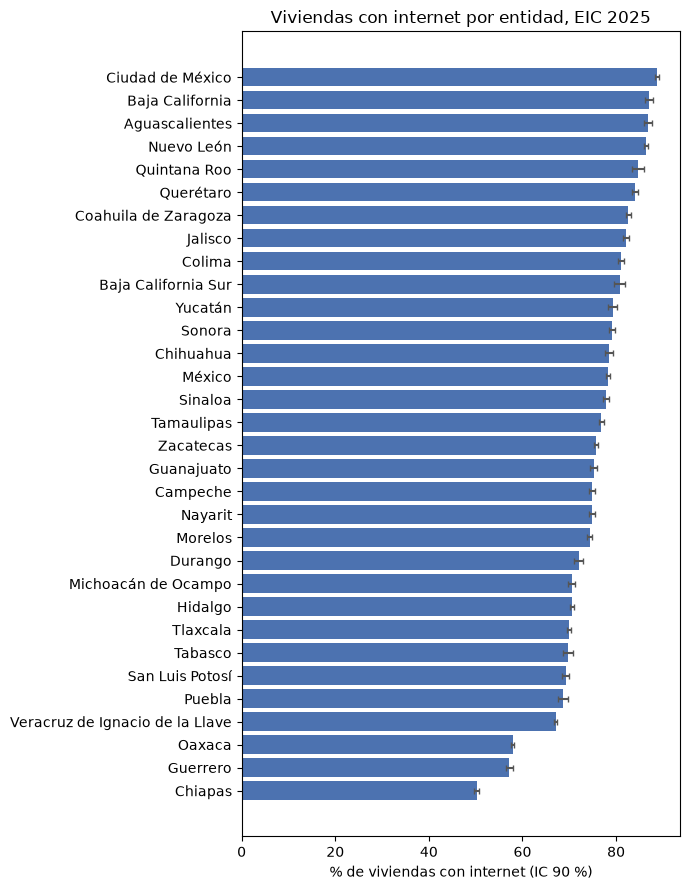

In [6]:
fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(inter["nombre"], inter["valor"], xerr=[inter["valor"] - inter["lim_inf"], inter["lim_sup"] - inter["valor"]],
        color="#4C72B0", ecolor="#555", capsize=2)
ax.set_xlabel("% de viviendas con internet (IC 90 %)")
ax.set_title("Viviendas con internet por entidad, EIC 2025")
plt.tight_layout()

## 4. Varios indicadores a la vez: de formato largo a ancho

In [7]:
datos = csv("/datasets/eic2025_localidades/datos?indicador=GRAPROES,PCN_PSINDER,PCN_HOG_ALIM_N,PCN_VPH_INTER&nivel=entidad")
ancho = datos.pivot(index="nombre", columns="indicador", values="valor")
ancho.corr().round(2)

indicador,GRAPROES,PCN_HOG_ALIM_N,PCN_PSINDER,PCN_VPH_INTER
indicador,,,,
GRAPROES,1.00,-0.39,-0.78,0.90
PCN_HOG_ALIM_N,-0.39,1.00,0.30,-0.49
PCN_PSINDER,-0.78,0.30,1.00,-0.74
PCN_VPH_INTER,0.90,-0.49,-0.74,1.00


Text(0.5, 1.0, 'Escolaridad frente a afiliación a la salud, por entidad')

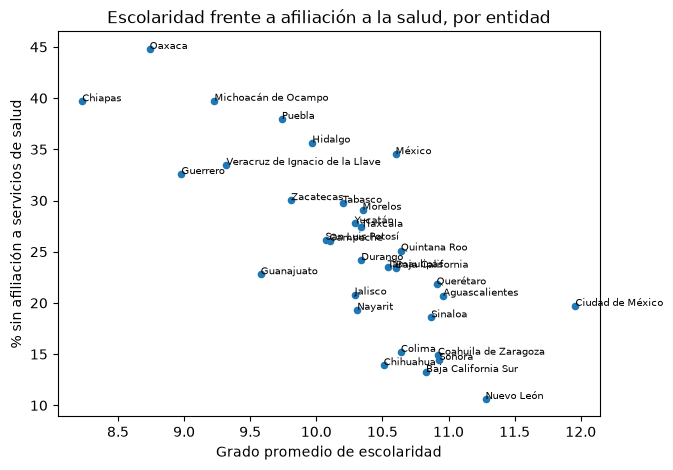

In [8]:
ax = ancho.plot.scatter(x="GRAPROES", y="PCN_PSINDER", figsize=(7, 5))
for nombre, fila in ancho.iterrows():
    ax.annotate(nombre, (fila["GRAPROES"], fila["PCN_PSINDER"]), fontsize=7)
ax.set_xlabel("Grado promedio de escolaridad")
ax.set_ylabel("% sin afiliación a servicios de salud")
ax.set_title("Escolaridad frente a afiliación a la salud, por entidad")

## 5. Rankings calculados en el servidor

Los 15 municipios con mayor porcentaje de población sin afiliación a servicios de salud, descartando estimaciones de precisión baja.

In [9]:
csv("/datasets/eic2025_localidades/ranking?indicador=PCN_PSINDER&nivel=municipio&n=15&excluir_baja_precision=true")[["posicion", "nombre", "nom_ent", "valor", "coef_var", "precision"]]

,posicion,nombre,nom_ent,valor,coef_var,precision
0,1,Tenampa,Veracruz de Ignacio de la Llave,95.38,0.72,alta
1,2,Santa Catarina Loxicha,Oaxaca,94.11,0.00,alta
2,3,San Juan Diuxi,Oaxaca,92.83,0.00,alta
3,4,Santo Domingo Albarradas,Oaxaca,91.93,0.00,alta
4,5,Magdalena Mixtepec,Oaxaca,91.64,0.00,alta
5,6,Celestún,Yucatán,91.25,1.06,alta
6,7,Yogana,Oaxaca,91.01,0.00,alta
7,8,Santo Domingo Roayaga,Oaxaca,90.77,0.00,alta
8,9,Totontepec Villa de Morelos,Oaxaca,90.70,2.41,alta
9,10,Sochiapa,Veracruz de Ignacio de la Llave,90.15,0.00,alta


## 6. Perfil de un lugar frente a su entidad y el país

`/ubicar` convierte un nombre en su clave `cvegeo`; `/perfil` devuelve JSON anidado, que aplanamos con `json_normalize`.

In [10]:
lugar = csv("/ubicar?q=Zapopan").iloc[0]
lugar[["cvegeo", "nombre", "nivel", "nom_ent"]]

cvegeo     141200000
nombre       Zapopan
nivel      municipio
nom_ent      Jalisco
Name: 0, dtype: object

In [11]:
perfil = js(f"/datasets/eic2025_localidades/perfil/{lugar.cvegeo}?conjunto=vulnerabilidad")
tabla = pd.json_normalize(perfil["indicadores"])
tabla[["nombre", "lugar.valor", "lugar.precision", "entidad.valor", "nacional.valor"]]

,nombre,lugar.valor,lugar.precision,entidad.valor,nacional.valor
0,Porcentaje de población no afiliada a servicios de salud,18.37,alta,20.82,27.26
1,Porcentaje de población de 15 años y más sin instrucción,1.75,alta,2.85,4.10
2,Porcentaje de población de 15 años y más analfabeta,1.34,moderada,2.20,3.69
3,Porcentaje de población de 6 a 14 años que no asiste a la escuela,3.18,moderada,4.27,3.70
4,Porcentaje de hogares donde no hubo acceso a los alimentos por falta de dine...,4.10,alta,5.45,6.54
5,Porcentaje de hogares en donde algún integrante de 18 años y más dejó de des...,3.86,alta,5.37,7.13
6,Porcentaje de hogares donde algún integrante menor de 18 años tuvo una alime...,6.48,moderada,8.45,10.85
7,Porcentaje de viviendas particulares habitadas con piso de tierra,0.54,moderada,0.88,2.21
8,Porcentaje de viviendas particulares habitadas con solo un cuarto,2.27,moderada,2.82,5.74
9,Porcentaje de viviendas particulares habitadas donde se dispone de agua entu...,99.71,alta,99.59,97.56


---
*Fuente: INEGI, Encuesta Intercensal 2015 y 2025. Datos servidos por [EIC API + MCP](https://github.com/zamax14/EIC-API-MCP).*